# 🐟 Multiclass Fish Image Classification — Local GPU (4GB VRAM)
### CNN from Scratch + VGG16 + ResNet50 + MobileNet + InceptionV3 + EfficientNetB0
---
> ⚡ Optimized for **4GB VRAM GPU** — uses mixed precision, memory growth, small batch size

## ✅ Step 1 — Install Requirements

In [1]:
!pip install tensorflow[and-cuda]==2.16.1

  Using cached tensorflow-2.16.1-cp310-cp310-win_amd64.whl (2.1 kB)
  Using cached tensorflow_intel-2.16.1-cp310-cp310-win_amd64.whl (376.9 MB)
     -------------------------------------- 122.5/122.5 MB 1.1 MB/s eta 0:00:00
     ---------------------------------------- 55.8/55.8 MB 1.5 MB/s eta 0:00:00
     ---------------------------------------- 97.8/97.8 MB 1.7 MB/s eta 0:00:00


ERROR: Could not find a version that satisfies the requirement nvidia-nccl-cu12==2.19.3; extra == "and-cuda" (from tensorflow[and-cuda]) (from versions: 0.0.1.dev5)
ERROR: No matching distribution found for nvidia-nccl-cu12==2.19.3; extra == "and-cuda"
You should consider upgrading via the 'C:\Users\sarav\Documents\CV_project\Fish_classification\env\Scripts\python.exe -m pip install --upgrade pip' command.


In [2]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[]


In [ ]:
!pip install numpy==1.26.4 matplotlib==3.7.1 seaborn==0.12.2 scikit-learn==1.2.2 pillow==9.5.0 plotly==5.14.1 pandas==2.0.3 ipywidgets==8.0.6 streamlit==1.28.0 ipykernel

     -------------------------------------- 719.4/719.4 MB 1.1 MB/s eta 0:00:00
     ---------------------------------------- 76.4/76.4 MB 2.2 MB/s eta 0:00:00
     -------------------------------------- 553.2/553.2 MB 2.3 MB/s eta 0:00:00


You should consider upgrading via the 'C:\Users\sarav\Documents\CV_project\Fish_classification\env\Scripts\python.exe -m pip install --upgrade pip' command.


In [7]:
# Find where it got installed
!pip show nvidia-cudnn-cu12

Name: nvidia-cudnn-cu12
Version: 8.9.7.29
Summary: cuDNN runtime libraries
Home-page: https://developer.nvidia.com/cuda-zone
Author: Nvidia CUDA Installer Team
Author-email: cuda_installer@nvidia.com
License: NVIDIA Proprietary Software
Location: c:\users\sarav\documents\cv_project\fish_classification\env\lib\site-packages
Requires: nvidia-cublas-cu12, nvidia-cuda-nvrtc-cu12
Required-by: 


In [ ]:
!set CUDNN_PATH=C:\Users\sarav\AppData\Local\Programs\Python\Python310\Lib\site-packages\nvidia\cudnn
!set PATH=%CUDNN_PATH%\bin;%PATH%

In [5]:
import tensorflow as tf
import sys
import subprocess

print("TF version     :", tf.__version__)
print("Python         :", sys.version)
print("GPU devices    :", tf.config.list_physical_devices('GPU'))
print("CUDA built     :", tf.test.is_built_with_cuda())

# Check nvidia-smi
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print("\nnvidia-smi output:")
print(result.stdout if result.returncode == 0 else "nvidia-smi not found!")

TF version     : 2.16.1
Python         : 3.10.5 (tags/v3.10.5:f377153, Jun  6 2022, 16:14:13) [MSC v.1929 64 bit (AMD64)]
GPU devices    : []
CUDA built     : False

nvidia-smi output:
Wed Feb 18 23:50:21 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 555.99                 Driver Version: 555.99         CUDA Version: 12.5     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3050 ...  WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   51C    P8              4W /   30W |    

In [3]:
import tensorflow as tf
print(tf.__version__)

2.16.1


In [ ]:
# # Run this cell once to install all dependencies
# import sys
# !{sys.executable} -m pip install tensorflow numpy matplotlib seaborn scikit-learn pillow plotly pandas ipywidgets

## ✅ Step 2 — GPU Setup & Memory Configuration

In [4]:
import tensorflow as tf

# ── Allow GPU memory to grow gradually (prevents OOM crash) ──
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f'✅ GPU found: {[g.name for g in gpus]}')
    print(f'   Memory growth enabled (4GB safe mode)')
else:
    print('⚠️  No GPU detected — will run on CPU (slower)')

# ── Mixed Precision (float16) — cuts VRAM usage nearly in half ──
tf.keras.mixed_precision.set_global_policy('mixed_float16')
print(f'\nMixed precision policy : {tf.keras.mixed_precision.global_policy().name}')
print(f'TensorFlow version     : {tf.__version__}')

⚠️  No GPU detected — will run on CPU (slower)

Mixed precision policy : mixed_float16
TensorFlow version     : 2.16.1


## ✅ Step 3 — Import Libraries

In [3]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16, ResNet50, MobileNet, InceptionV3, EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix

print('All libraries imported ✅')

All libraries imported ✅


## ✅ Step 4 — Configuration
> 👇 **Only change `DATASET_DIR`** to point to your fish dataset folder

In [4]:
# ─────────────────────────────────────────────────────────────
# 👇 SET YOUR DATASET PATH HERE
# The folder should contain sub-folders named after each species
# Example:
#   C:/Users/You/fish_dataset/
#       Bass/  img1.jpg  img2.jpg ...
#       Salmon/ ...
#       Tuna/   ...
# ─────────────────────────────────────────────────────────────
DATASET_DIR = r'C:\Users\sarav\Documents\CV_project\Fish_classification\data\train'

# ── Optimized for 4GB VRAM ───────────────────────────────────
IMG_SIZE    = (224, 224)   # standard size
BATCH_SIZE  = 16           # reduced from 32 → fits in 4GB VRAM
EPOCHS      = 20
SEED        = 42

MODEL_SAVE_DIR = 'saved_models'
RESULTS_DIR    = 'results'

os.makedirs(MODEL_SAVE_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR,    exist_ok=True)

# ── Verify dataset path ──────────────────────────────────────
if not os.path.exists(DATASET_DIR):
    print(f'❌ Dataset path not found: {DATASET_DIR}')
    print('   Please update DATASET_DIR above.')
else:
    classes = sorted([d for d in os.listdir(DATASET_DIR)
                      if os.path.isdir(os.path.join(DATASET_DIR, d))])
    print(f'✅ Dataset found!')
    print(f'   Path    : {DATASET_DIR}')
    print(f'   Classes : {len(classes)} → {classes}')
    print()
    for cls in classes:
        n = len(os.listdir(os.path.join(DATASET_DIR, cls)))
        print(f'   {cls:<25} {n} images')

✅ Dataset found!
   Path    : C:\Users\sarav\Documents\CV_project\Fish_classification\data\train
   Classes : 11 → ['animal fish', 'animal fish bass', 'fish sea_food black_sea_sprat', 'fish sea_food gilt_head_bream', 'fish sea_food hourse_mackerel', 'fish sea_food red_mullet', 'fish sea_food red_sea_bream', 'fish sea_food sea_bass', 'fish sea_food shrimp', 'fish sea_food striped_red_mullet', 'fish sea_food trout']

   animal fish               1096 images
   animal fish bass          30 images
   fish sea_food black_sea_sprat 569 images
   fish sea_food gilt_head_bream 566 images
   fish sea_food hourse_mackerel 573 images
   fish sea_food red_mullet  579 images
   fish sea_food red_sea_bream 571 images
   fish sea_food sea_bass    538 images
   fish sea_food shrimp      576 images
   fish sea_food striped_red_mullet 547 images
   fish sea_food trout       580 images


## ✅ Step 5 — Data Preprocessing & Augmentation

In [5]:
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1,
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    rescale=1.0/255,
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=SEED
)

val_gen = val_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=SEED,
    shuffle=False
)

NUM_CLASSES = train_gen.num_classes
CLASS_NAMES = list(train_gen.class_indices.keys())

with open(os.path.join(MODEL_SAVE_DIR, 'class_names.json'), 'w') as f:
    json.dump(CLASS_NAMES, f)

print(f'Training samples   : {train_gen.samples}')
print(f'Validation samples : {val_gen.samples}')
print(f'Number of classes  : {NUM_CLASSES}')
print(f'Batch size         : {BATCH_SIZE}  (4GB VRAM safe)')

Found 4984 images belonging to 11 classes.
Found 1241 images belonging to 11 classes.
Training samples   : 4984
Validation samples : 1241
Number of classes  : 11
Batch size         : 16  (4GB VRAM safe)


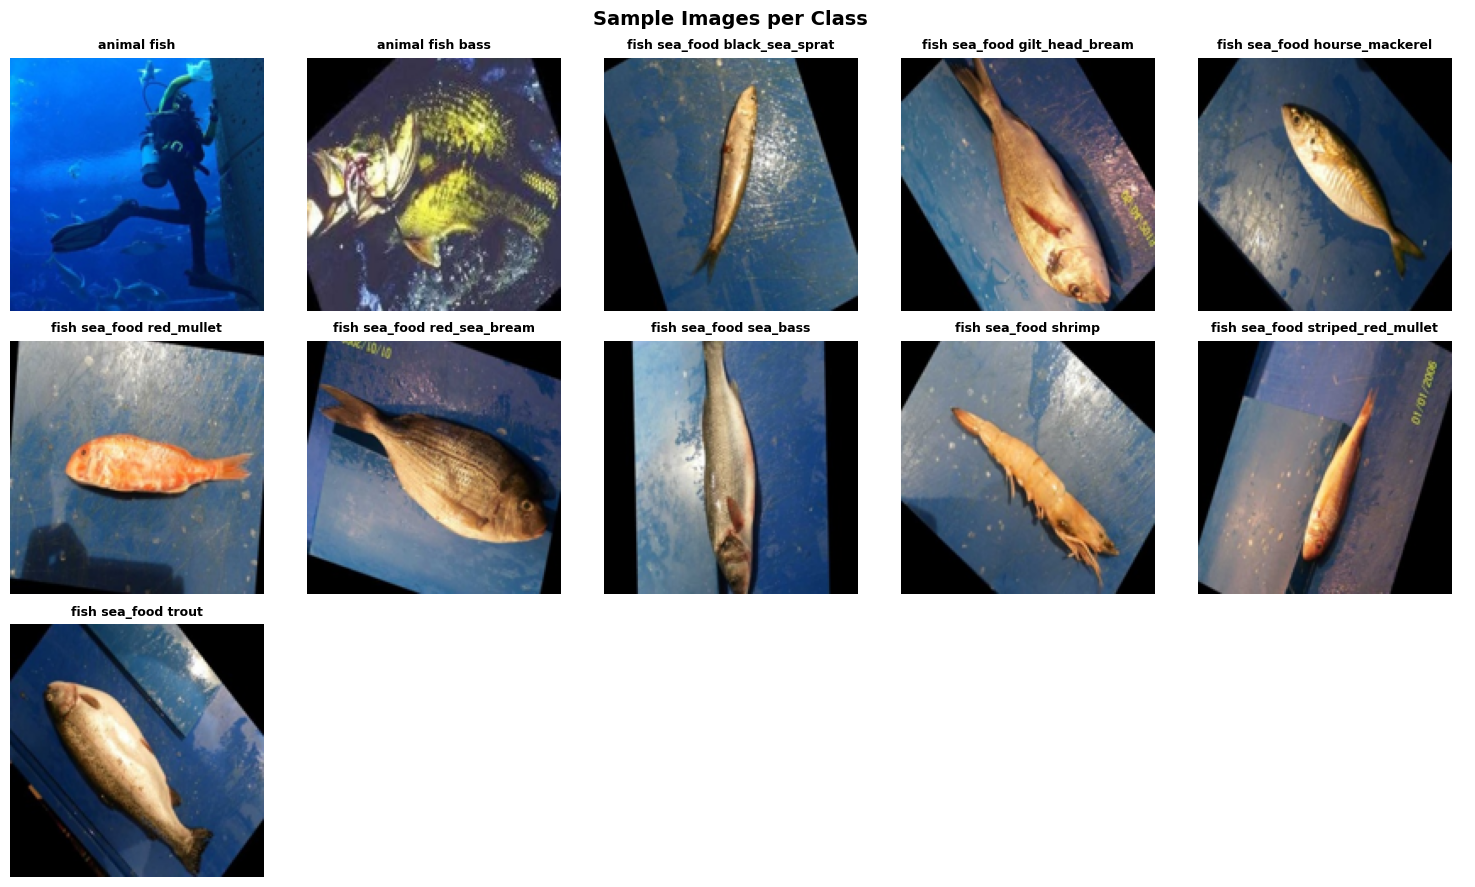

In [6]:
# ── Visualize sample images ──────────────────────────────────
n_cols = min(5, NUM_CLASSES)
n_rows = (NUM_CLASSES + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3))
axes = np.array(axes).flatten()

for i, cls in enumerate(CLASS_NAMES):
    folder = os.path.join(DATASET_DIR, cls)
    imgs   = [f for f in os.listdir(folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if imgs:
        img = Image.open(os.path.join(folder, imgs[0])).resize((150, 150))
        axes[i].imshow(img)
        axes[i].set_title(cls, fontsize=9, fontweight='bold')
    axes[i].axis('off')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Sample Images per Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'sample_images.png'), dpi=120)
plt.show()

## ✅ Step 6 — Helper Functions

In [7]:
# ── Shared training results store ────────────────────────────
all_histories = {}
all_reports   = {}
model_map     = {}


def get_callbacks(model_name):
    return [
        EarlyStopping(patience=5, restore_best_weights=True, monitor='val_accuracy'),
        ModelCheckpoint(
            filepath=os.path.join(MODEL_SAVE_DIR, f'{model_name}.h5'),
            save_best_only=True,
            monitor='val_accuracy',
            verbose=0
        ),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3,
                          min_lr=1e-6, verbose=1)
    ]


def compile_and_train(model, model_name, train_g=None, val_g=None, lr=1e-3):
    """Compile + train a model, store history."""
    if train_g is None: train_g = train_gen
    if val_g   is None: val_g   = val_gen

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    print(f'\n{"="*55}')
    print(f'  Training : {model_name}')
    print(f'  Params   : {model.count_params():,}')
    print(f'{"="*55}')

    history = model.fit(
        train_g,
        epochs=EPOCHS,
        validation_data=val_g,
        callbacks=get_callbacks(model_name),
        verbose=1
    )
    all_histories[model_name] = history
    model_map[model_name]     = model
    return history


def plot_history(model_name):
    """Plot accuracy & loss curves for a trained model."""
    hist = all_histories[model_name].history

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Training History — {model_name}', fontsize=14, fontweight='bold')

    # Accuracy
    axes[0].plot(hist['accuracy'],     label='Train', color='royalblue', linewidth=2)
    axes[0].plot(hist['val_accuracy'], label='Val',   color='tomato',    linewidth=2, linestyle='--')
    axes[0].set_title('Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    best_val_acc = max(hist['val_accuracy'])
    axes[0].annotate(f'Best: {best_val_acc:.4f}',
                     xy=(np.argmax(hist['val_accuracy']), best_val_acc),
                     xytext=(5, -15), textcoords='offset points',
                     color='tomato', fontweight='bold')

    # Loss
    axes[1].plot(hist['loss'],     label='Train', color='royalblue', linewidth=2)
    axes[1].plot(hist['val_loss'], label='Val',   color='tomato',    linewidth=2, linestyle='--')
    axes[1].set_title('Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    save_path = os.path.join(RESULTS_DIR, f'{model_name}_history.png')
    plt.savefig(save_path, dpi=120)
    plt.show()
    print(f'  Saved → {save_path}')


def evaluate_model(model, model_name, val_g=None):
    """Predict, print classification report, plot confusion matrix."""
    if val_g is None: val_g = val_gen
    val_g.reset()

    preds  = model.predict(val_g, verbose=1)
    y_pred = np.argmax(preds, axis=1)
    y_true = val_g.classes

    report = classification_report(
        y_true, y_pred, target_names=CLASS_NAMES, output_dict=True
    )
    print(f'\n── {model_name} — Classification Report ──')
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

    cm = confusion_matrix(y_true, y_pred)
    fig_size = max(8, NUM_CLASSES)
    plt.figure(figsize=(fig_size, fig_size - 2))
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                cmap='Blues', linewidths=0.4)
    plt.title(f'Confusion Matrix — {model_name}', fontsize=13, fontweight='bold')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    save_path = os.path.join(RESULTS_DIR, f'{model_name}_confusion_matrix.png')
    plt.savefig(save_path, dpi=120)
    plt.show()
    print(f'  Saved → {save_path}')

    all_reports[model_name] = report
    return report


def build_transfer_model(base_class, num_classes, input_shape=(*IMG_SIZE, 3)):
    """Generic transfer learning model builder."""
    base = base_class(weights='imagenet', include_top=False, input_shape=input_shape)
    base.trainable = False
    x   = base.output
    x   = layers.GlobalAveragePooling2D()(x)
    x   = layers.Dense(256, activation='relu')(x)
    x   = layers.Dropout(0.4)(x)
    # float32 output required for mixed precision stability
    out = layers.Dense(num_classes, activation='softmax', dtype='float32')(x)
    return models.Model(inputs=base.input, outputs=out)


# Flush GPU memory between models
def clear_gpu():
    import gc
    gc.collect()
    tf.keras.backend.clear_session()

print('Helper functions ready ✅')

Helper functions ready ✅


## ✅ Step 7 — Model 1: CNN from Scratch

In [8]:
cnn_scratch = models.Sequential([
    # Block 1
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(*IMG_SIZE, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    # Block 2
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    # Block 3
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    # Block 4
    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    # Classifier
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax', dtype='float32')
], name='CNN_Scratch')

cnn_scratch.summary()

Model: "CNN_Scratch"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    25,690,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │         5,643 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,086,603 (99.51 MB)

 Trainable params: 26,085,643 (99.51 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
compile_and_train(cnn_scratch, 'CNN_Scratch')


  Training : CNN_Scratch
  Params   : 26,086,603
Epoch 1/20
  3/312 ━━━━━━━━━━━━━━━━━━━━ 3:01:42 35s/step - accuracy: 0.0694 - loss: 4.9788

In [ ]:
plot_history('CNN_Scratch')

In [ ]:
evaluate_model(cnn_scratch, 'CNN_Scratch')
clear_gpu()

## ✅ Step 8 — Model 2: VGG16

In [ ]:
vgg16_model = build_transfer_model(VGG16, NUM_CLASSES)
compile_and_train(vgg16_model, 'VGG16')

In [ ]:
plot_history('VGG16')

In [ ]:
evaluate_model(vgg16_model, 'VGG16')
clear_gpu()

## ✅ Step 9 — Model 3: ResNet50

In [ ]:
resnet_model = build_transfer_model(ResNet50, NUM_CLASSES)
compile_and_train(resnet_model, 'ResNet50')

In [ ]:
plot_history('ResNet50')

In [ ]:
evaluate_model(resnet_model, 'ResNet50')
clear_gpu()

## ✅ Step 10 — Model 4: MobileNet

In [ ]:
mobilenet_model = build_transfer_model(MobileNet, NUM_CLASSES)
compile_and_train(mobilenet_model, 'MobileNet')

In [ ]:
plot_history('MobileNet')

In [ ]:
evaluate_model(mobilenet_model, 'MobileNet')
clear_gpu()

## ✅ Step 11 — Model 5: InceptionV3
> Needs 299×299 — separate generators created automatically

In [ ]:
INCEPTION_SIZE = (299, 299)

inc_train_gen = ImageDataGenerator(
    rescale=1.0/255, rotation_range=20, zoom_range=0.2,
    horizontal_flip=True, validation_split=0.2
).flow_from_directory(
    DATASET_DIR, target_size=INCEPTION_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical',
    subset='training', seed=SEED
)

inc_val_gen = ImageDataGenerator(
    rescale=1.0/255, validation_split=0.2
).flow_from_directory(
    DATASET_DIR, target_size=INCEPTION_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical',
    subset='validation', seed=SEED, shuffle=False
)

inception_model = build_transfer_model(InceptionV3, NUM_CLASSES, input_shape=(299, 299, 3))
compile_and_train(inception_model, 'InceptionV3', train_g=inc_train_gen, val_g=inc_val_gen)

In [ ]:
plot_history('InceptionV3')

In [ ]:
evaluate_model(inception_model, 'InceptionV3', val_g=inc_val_gen)
clear_gpu()

## ✅ Step 12 — Model 6: EfficientNetB0

In [ ]:
efficient_model = build_transfer_model(EfficientNetB0, NUM_CLASSES)
compile_and_train(efficient_model, 'EfficientNetB0')

In [ ]:
plot_history('EfficientNetB0')

In [ ]:
evaluate_model(efficient_model, 'EfficientNetB0')
clear_gpu()

## ✅ Step 13 — All Models: Combined Training History

In [ ]:
model_names = list(all_histories.keys())
n           = len(model_names)
colors      = ['royalblue', 'seagreen', 'darkorange', 'purple', 'crimson', 'teal']

fig, axes = plt.subplots(n, 2, figsize=(16, n * 4))
fig.suptitle('Training History — All Models', fontsize=16, fontweight='bold', y=1.01)

for i, name in enumerate(model_names):
    hist = all_histories[name].history
    c    = colors[i % len(colors)]

    # Accuracy plot
    axes[i][0].plot(hist['accuracy'],     label='Train Acc', color=c,      linewidth=2)
    axes[i][0].plot(hist['val_accuracy'], label='Val Acc',   color='gray', linewidth=2, linestyle='--')
    axes[i][0].set_title(f'{name} — Accuracy', fontweight='bold')
    axes[i][0].set_xlabel('Epoch')
    axes[i][0].set_ylabel('Accuracy')
    axes[i][0].set_ylim(0, 1.05)
    axes[i][0].legend()
    axes[i][0].grid(alpha=0.3)

    # Loss plot
    axes[i][1].plot(hist['loss'],     label='Train Loss', color=c,      linewidth=2)
    axes[i][1].plot(hist['val_loss'], label='Val Loss',   color='gray', linewidth=2, linestyle='--')
    axes[i][1].set_title(f'{name} — Loss', fontweight='bold')
    axes[i][1].set_xlabel('Epoch')
    axes[i][1].set_ylabel('Loss')
    axes[i][1].legend()
    axes[i][1].grid(alpha=0.3)

plt.tight_layout()
save_path = os.path.join(RESULTS_DIR, 'all_models_history.png')
plt.savefig(save_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'Combined history saved → {save_path} ✅')

## ✅ Step 14 — Model Comparison Report

In [ ]:
rows = [
    {
        'Model':     name,
        'Accuracy':  round(rpt['accuracy'], 4),
        'Precision': round(rpt['weighted avg']['precision'], 4),
        'Recall':    round(rpt['weighted avg']['recall'], 4),
        'F1-Score':  round(rpt['weighted avg']['f1-score'], 4),
    }
    for name, rpt in all_reports.items()
]

comparison_df = pd.DataFrame(rows).sort_values('Accuracy', ascending=False).reset_index(drop=True)
comparison_df.to_json(os.path.join(RESULTS_DIR, 'comparison_report.json'), orient='records', indent=2)

display(
    comparison_df.style
    .highlight_max(subset=['Accuracy','Precision','Recall','F1-Score'], color='lightgreen')
    .highlight_min(subset=['Accuracy','Precision','Recall','F1-Score'], color='#ffcccc')
    .format({'Accuracy':'{:.4f}','Precision':'{:.4f}','Recall':'{:.4f}','F1-Score':'{:.4f}'})
    .set_caption('🏆 Model Comparison — Green = Best | Red = Lowest')
)

In [ ]:
# ── Bar Chart ────────────────────────────────────────────────
metrics     = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x           = np.arange(len(comparison_df))
width       = 0.2
bar_colors  = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']

fig, ax = plt.subplots(figsize=(14, 6))
for i, (metric, color) in enumerate(zip(metrics, bar_colors)):
    bars = ax.bar(x + i * width, comparison_df[metric], width,
                  label=metric, color=color, alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(comparison_df['Model'], rotation=15, ha='right')
ax.set_ylim(0, 1.15)
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score',  fontsize=12)
ax.set_title('Model Comparison — All Metrics', fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'model_comparison_chart.png'), dpi=120)
plt.show()
print('Comparison chart saved ✅')

## ✅ Step 15 — Save Best Model

In [ ]:
best_name = comparison_df.iloc[0]['Model']
best_acc  = comparison_df.iloc[0]['Accuracy']
best_model = model_map[best_name]

best_path = os.path.join(MODEL_SAVE_DIR, 'best_model.h5')
best_model.save(best_path)

with open(os.path.join(MODEL_SAVE_DIR, 'best_model_name.json'), 'w') as f:
    json.dump({'best_model': best_name, 'accuracy': float(best_acc)}, f)

print(f'🏆 Best Model : {best_name}')
print(f'   Accuracy   : {best_acc:.4f}')
print(f'   Saved to   : {best_path}')

## ✅ Step 16 — Test Single Image Prediction

In [ ]:
def predict_image(img_path, model=None, class_names=CLASS_NAMES, img_size=IMG_SIZE):
    if model is None:
        model = tf.keras.models.load_model(os.path.join(MODEL_SAVE_DIR, 'best_model.h5'))

    img = Image.open(img_path).convert('RGB').resize(img_size)
    arr = np.expand_dims(np.array(img, dtype=np.float32) / 255.0, axis=0)

    preds     = model.predict(arr, verbose=0)[0]
    top_idx   = int(np.argmax(preds))
    top_class = class_names[top_idx]
    top_conf  = float(preds[top_idx])

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].imshow(img)
    axes[0].set_title(f'Prediction : {top_class}\nConfidence : {top_conf*100:.2f}%',
                      fontsize=12, fontweight='bold', color='darkgreen')
    axes[0].axis('off')

    top_n   = min(10, len(class_names))
    sorted_idx = np.argsort(preds)[::-1][:top_n]
    bar_cols   = ['#2ecc71' if i == top_idx else '#3498db' for i in sorted_idx]

    axes[1].barh(
        [class_names[i] for i in sorted_idx[::-1]],
        [preds[i]       for i in sorted_idx[::-1]],
        color=bar_cols[::-1]
    )
    axes[1].set_xlim(0, 1)
    axes[1].set_xlabel('Confidence')
    axes[1].set_title('Top Class Probabilities')
    axes[1].grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()
    return top_class, top_conf


# ── Test with an image ───────────────────────────────────────
TEST_IMAGE = r'C:\path\to\test_fish.jpg'   # <-- CHANGE THIS

if os.path.exists(TEST_IMAGE):
    cls, conf = predict_image(TEST_IMAGE, best_model)
    print(f'\n🐠 Predicted : {cls}  |  Confidence : {conf*100:.2f}%')
else:
    print('Test image not found. Update TEST_IMAGE path above.')

## ✅ Step 17 — Generate Streamlit App File
> After running this cell, open a terminal and run: `streamlit run app.py`

In [ ]:
app_code = '''
import os, json
import numpy as np
from PIL import Image
import streamlit as st
import tensorflow as tf
import pandas as pd
import plotly.graph_objects as go

MODEL_PATH = "saved_models/best_model.h5"
NAMES_PATH = "saved_models/class_names.json"
IMG_SIZE   = (224, 224)
RESULTS    = "results"

st.set_page_config(page_title="Fish Classifier", page_icon="🐟", layout="wide")

@st.cache_resource
def load_model():
    gpus = tf.config.list_physical_devices("GPU")
    if gpus:
        tf.config.experimental.set_memory_growth(gpus[0], True)
    return tf.keras.models.load_model(MODEL_PATH)

@st.cache_data
def load_names():
    with open(NAMES_PATH) as f: return json.load(f)

with st.sidebar:
    st.title("🐟 Fish Classifier")
    st.markdown("---")
    info_path = "saved_models/best_model_name.json"
    if os.path.exists(info_path):
        with open(info_path) as f: info = json.load(f)
        st.success(f"Best Model: {info[\"best_model\"]}")
        st.metric("Val Accuracy", f"{info[\"accuracy\"]*100:.2f}%")
    page = st.radio("Navigate", ["🔍 Predict", "📊 Comparison", "📈 History"])

model, class_names = load_model(), load_names()

if page == "🔍 Predict":
    st.title("🐟 Fish Species Classifier")
    uploaded = st.file_uploader("Upload a fish image", type=["jpg","jpeg","png"])
    if uploaded:
        img = Image.open(uploaded)
        col1, col2 = st.columns(2)
        with col1:
            st.image(img, caption="Uploaded Image", use_container_width=True)
        with col2:
            arr   = np.expand_dims(np.array(img.convert("RGB").resize(IMG_SIZE), dtype=np.float32)/255., 0)
            preds = model.predict(arr, verbose=0)[0]
            idx   = int(np.argmax(preds))
            st.success(f"**Prediction: {class_names[idx]}**")
            st.metric("Confidence", f"{preds[idx]*100:.2f}%")
            st.progress(float(preds[idx]))
            fig = go.Figure(go.Bar(
                x=list(preds), y=class_names, orientation="h",
                marker_color=["#2ecc71" if i==idx else "#3498db" for i in range(len(class_names))],
                text=[f"{v*100:.1f}%" for v in preds], textposition="outside"
            ))
            fig.update_layout(title="Class Probabilities", xaxis_range=[0,1.2],
                              height=max(400, len(class_names)*35))
            st.plotly_chart(fig, use_container_width=True)

elif page == "📊 Comparison":
    st.title("📊 Model Comparison")
    rpt = os.path.join(RESULTS, "comparison_report.json")
    if os.path.exists(rpt):
        df = pd.read_json(rpt)
        st.dataframe(df.style.highlight_max(
            subset=["Accuracy","Precision","Recall","F1-Score"], color="lightgreen"),
            use_container_width=True)
        chart_path = os.path.join(RESULTS, "model_comparison_chart.png")
        if os.path.exists(chart_path):
            st.image(chart_path, use_container_width=True)
    else:
        st.warning("Run the notebook first to generate results.")

elif page == "📈 History":
    st.title("📈 Training History")
    hist_img = os.path.join(RESULTS, "all_models_history.png")
    if os.path.exists(hist_img):
        st.image(hist_img, caption="All Models Training History", use_container_width=True)
    hist_files = [f for f in os.listdir(RESULTS) if f.endswith("_history.png") and "all" not in f]
    for hf in sorted(hist_files):
        st.markdown(f"**{hf.replace(\'_history.png\', \'\')}**")
        st.image(os.path.join(RESULTS, hf), use_container_width=True)
'''

with open('app.py', 'w') as f:
    f.write(app_code.strip())

print('✅ app.py created!')
print()
print('To launch the Streamlit app, open a terminal in this folder and run:')
print('   streamlit run app.py')

---
## 🎉 All Done!

| Step | Task | Status |
|---|---|---|
| 1 | GPU memory growth + Mixed Precision | ✅ |
| 2 | Data Preprocessing & Augmentation | ✅ |
| 3 | CNN from Scratch | ✅ |
| 4 | VGG16 Transfer Learning | ✅ |
| 5 | ResNet50 Transfer Learning | ✅ |
| 6 | MobileNet Transfer Learning | ✅ |
| 7 | InceptionV3 Transfer Learning | ✅ |
| 8 | EfficientNetB0 Transfer Learning | ✅ |
| 9 | Training History Plots (per model + combined) | ✅ |
| 10 | Confusion Matrices | ✅ |
| 11 | Model Comparison Report | ✅ |
| 12 | Best Model Saved (.h5) | ✅ |
| 13 | Streamlit App (app.py) | ✅ |